# Week 4 – Model Development, Benchmarking, Deployment, and Monitoring Prep

This notebook builds on the Week 3 SDWA pipeline:

1. Load the train/validation/test/production splits created in Week 3.  
2. Engineer a binary label indicating high‑risk vs normal‑risk systems.  
3. Implement a simple benchmark model for comparison.  
4. Train and evaluate an XGBoost model in SageMaker.  
5. Deploy the model using a Batch Transform job.  
6. Prepare monitoring baselines and schema artifacts for Week 5.

The data consists of PWS × Quarter‑level engineered features derived from SDWA sources.


In [1]:
# ============================================
# 1. Environment setup and data loading
# ============================================

import boto3
import awswrangler as wr
import pandas as pd
import sagemaker
from sagemaker.session import Session

# Set AWS region and create a Boto3 + SageMaker session
region = "us-east-1"
session = boto3.Session(region_name=region)
sm_session = Session(boto_session=session)

# Get the execution role attached to this SageMaker notebook instance
role_arn = sagemaker.get_execution_role()

# S3 locations for engineered feature tables and splits
bucket = "aai540-group5-public-866792937762-us-east-1-an"
parquet_prefix = "sdwa/parquet/"
features_table_name = "sdwa_pws_quarter_features"

# Paths to Week 3 train/val/test/prod splits
train_path = f"s3://{bucket}/{parquet_prefix}{features_table_name}_train/"
val_path   = f"s3://{bucket}/{parquet_prefix}{features_table_name}_val/"
test_path  = f"s3://{bucket}/{parquet_prefix}{features_table_name}_test/"
prod_path  = f"s3://{bucket}/{parquet_prefix}{features_table_name}_prod/"

# Load the splits as DataFrames
train_df = wr.s3.read_parquet(train_path, dataset=True)
val_df   = wr.s3.read_parquet(val_path,   dataset=True)
test_df  = wr.s3.read_parquet(test_path,  dataset=True)
prod_df  = wr.s3.read_parquet(prod_path,  dataset=True)

# Quick sanity check on shapes
print("Train:", train_df.shape)
print("Val:  ", val_df.shape)
print("Test: ", test_df.shape)
print("Prod: ", prod_df.shape)


sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml


2026-06-04 03:06:47,339	WARNING services.py:2137 -- WARNING: The object store is using /tmp instead of /dev/shm because /dev/shm has only 1908367360 bytes available. This will harm performance! You may be able to free up space by deleting files in /dev/shm. If you are inside a Docker container, you can increase /dev/shm size by passing '--shm-size=3.65gb' to 'docker run' (or add it to the run_options list in a Ray cluster config). Make sure to set this to more than 30% of available RAM.
2026-06-04 03:06:47,485	INFO worker.py:2007 -- Started a local Ray instance.
/opt/conda/lib/python3.12/site-packages/ray/_private/worker.py:2046: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(


Train: (173479, 14)
Val:   (43369, 14)
Test:  (43369, 14)
Prod:  (173481, 14)


## 2. Label engineering and numeric coercion

We create a binary label `label_high_risk` indicating whether a PWS had any violations in the quarter.  
We also coerce key numeric columns to numeric types to avoid downstream type issues.


In [2]:
# ============================================
# 2. Label engineering
# ============================================

# Columns that should be numeric for modeling
numeric_cols = [
    "total_violations",
    "health_based_violations",
    "major_violations",
    "lcr_sample_count",
    "lcr_max_measure",
    "lcr_mean_measure",
    "violations_per_1k_pop",
    "population_served_count",
]

def prepare_split(df: pd.DataFrame) -> pd.DataFrame:
    """
    Coerce numeric columns to numeric types and create a binary label:
    label_high_risk = 1 if total_violations > 0 else 0.
    """
    df = df.copy()
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    df["label_high_risk"] = (df["total_violations"] > 0).astype(int)
    return df

# Apply label engineering to all splits
train_df = prepare_split(train_df)
val_df   = prepare_split(val_df)
test_df  = prepare_split(test_df)
prod_df  = prepare_split(prod_df)

# Inspect label distribution in the training set
print(train_df["label_high_risk"].value_counts())


label_high_risk
1    103312
0     70167
Name: count, dtype: int64


## 3. Leakage removal and feature matrix construction

We remove:

- Identifier columns (non‑predictive, not suitable as features)  
- Outcome‑derived leakage columns (directly derived from violations)

Then we build `X` (features) and `y` (labels) for each split.


In [3]:
# ============================================
# 3. Leakage removal and feature matrix
# ============================================

from sklearn.metrics import classification_report, roc_auc_score
import numpy as np

# Non-predictive identifiers and metadata
drop_cols = [
    "record_id",
    "event_time",
    "pwsid",
    "submissionyearquarter",
    "pws_name",
    "epa_region",
]

# Outcome-derived leakage columns (must be removed)
leakage_cols = [
    "total_violations",
    "health_based_violations",
    "major_violations",
    "violations_per_1k_pop",
]

def build_X_y(df: pd.DataFrame):
    """
    Remove ID and leakage columns, then split into features X and label y.
    """
    df = df.copy()
    for c in drop_cols + leakage_cols:
        if c in df.columns:
            df = df.drop(columns=[c])
    y = df["label_high_risk"]
    X = df.drop(columns=["label_high_risk"])
    return X, y

# Build feature matrices and labels for all splits
X_train, y_train = build_X_y(train_df)
X_val,   y_val   = build_X_y(val_df)
X_test,  y_test  = build_X_y(test_df)
X_prod,  y_prod  = build_X_y(prod_df)

print("Train:", X_train.shape)
print("Val:  ", X_val.shape)
print("Test: ", X_test.shape)


Train: (173479, 6)
Val:   (43369, 6)
Test:  (43369, 6)


## 4. Benchmark model

We implement a simple heuristic benchmark:

> Predict high‑risk if `population_served_count < 500`.

This reflects EPA’s observation that small systems often struggle with compliance and serves as a baseline for comparison.


In [4]:
def benchmark_predict(X):
    return (X["population_served_count"] < 500).astype(int).values

y_pred_bench = benchmark_predict(X_test)
y_score_bench = y_pred_bench.astype(float)

print(classification_report(y_test, y_pred_bench, digits=3))
print("Benchmark ROC AUC:", roc_auc_score(y_test, y_score_bench))


              precision    recall  f1-score   support

           0      0.206     0.057     0.090     17337
           1      0.576     0.853     0.687     26032

    accuracy                          0.535     43369
   macro avg      0.391     0.455     0.389     43369
weighted avg      0.428     0.535     0.449     43369

Benchmark ROC AUC: 0.45499809619311654


## 5. Export train/validation/test splits to CSV for SageMaker XGBoost

The built‑in SageMaker XGBoost container expects CSV input with the label in the first column.  
We write train, validation, and test splits to S3 in that format.


In [5]:
# ============================================
# 5. CSV export for XGBoost training
# ============================================

# S3 paths for CSV versions of the splits
train_csv_path = f"s3://{bucket}/{parquet_prefix}{features_table_name}_train.csv"
val_csv_path   = f"s3://{bucket}/{parquet_prefix}{features_table_name}_val.csv"
test_csv_path  = f"s3://{bucket}/{parquet_prefix}{features_table_name}_test.csv"

# Concatenate label and features so that label is the first column
train_csv_df = pd.concat([y_train, X_train], axis=1)
val_csv_df   = pd.concat([y_val,   X_val],   axis=1)
test_csv_df  = pd.concat([y_test,  X_test],  axis=1)

# Write CSVs to S3
wr.s3.to_csv(train_csv_df, train_csv_path, index=False)
wr.s3.to_csv(val_csv_df,   val_csv_path,   index=False)
wr.s3.to_csv(test_csv_df,  test_csv_path,  index=False)

print("CSV export complete.")


CSV export complete.


## 6. Train XGBoost model in SageMaker

We use the built‑in XGBoost container in SageMaker to train a binary classifier on the leak‑free feature set.


In [6]:
# ============================================
# 6. XGBoost training (SageMaker)
# ============================================

from sagemaker.estimator import Estimator
from sagemaker.inputs import TrainingInput

# Retrieve the XGBoost container image URI
xgb_image = sagemaker.image_uris.retrieve(
    framework="xgboost",
    region=region,
    version="1.5-1",
)

# Output location for model artifacts
output_path = f"s3://{bucket}/{parquet_prefix}week4/xgb-output/"

# XGBoost hyperparameters
hyperparameters = {
    "max_depth": "5",
    "eta": "0.2",
    "gamma": "4",
    "min_child_weight": "6",
    "subsample": "0.7",
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "num_round": "100",
}

# Define the SageMaker Estimator
xgb_estimator = Estimator(
    image_uri=xgb_image,
    role=role_arn,
    instance_count=1,
    instance_type="ml.m5.large",
    output_path=output_path,
    hyperparameters=hyperparameters,
    sagemaker_session=sm_session,
)

# Wrap CSV paths as TrainingInput objects
train_input = TrainingInput(train_csv_path, content_type="text/csv")
val_input   = TrainingInput(val_csv_path,   content_type="text/csv")

# Launch training job
xgb_estimator.fit({"train": train_input, "validation": val_input})


INFO:sagemaker:Creating training-job with name: sagemaker-xgboost-2026-06-04-03-06-54-378


2026-06-04 03:06:54 Starting - Starting the training job...
2026-06-04 03:07:11 Starting - Preparing the instances for training...
2026-06-04 03:07:35 Downloading - Downloading input data......
2026-06-04 03:08:25 Downloading - Downloading the training image...../miniconda3/lib/python3.8/site-packages/xgboost/compat.py:36: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import MultiIndex, Int64Index
[2026-06-04 03:09:31.836 ip-10-0-249-150.ec2.internal:8 INFO utils.py:28] RULE_JOB_STOP_SIGNAL_FILENAME: None
[2026-06-04 03:09:31.867 ip-10-0-249-150.ec2.internal:8 INFO profiler_config_parser.py:111] User has disabled profiler.
[2026-06-04:03:09:32:INFO] Imported framework sagemaker_xgboost_container.training
[2026-06-04:03:09:32:INFO] Failed to parse hyperparameter eval_metric value auc to Json.
Returning the value itself
[2026-06-04:03:09:32:INFO] Failed to parse hyperp

## 7. Local evaluation of the trained XGBoost model

We download the trained model artifact, load it with the local XGBoost library,  
and evaluate it on the test set using the same leak‑free features.


In [7]:
# ============================================
# 7. Model evaluation and benchmark comparison
# ============================================

import xgboost as xgb_local
import tempfile
import os
import tarfile
from sklearn.metrics import confusion_matrix

# S3 path to the trained model artifact (model.tar.gz)
model_artifact = xgb_estimator.model_data
print("Model artifact:", model_artifact)

# Build a local test matrix with numeric features only
test_local = test_csv_df.copy()

# Extract label as a NumPy array
y_test_local = test_local["label_high_risk"].astype(int).values

# Drop label column to get features only
X_test_local = test_local.drop(columns=["label_high_risk"])

# Convert all feature columns to numeric and fill missing values with 0
X_test_local = X_test_local.apply(pd.to_numeric, errors="coerce").fillna(0)

# Convert to NumPy array for XGBoost DMatrix
X_test_local = X_test_local.values

# Download and extract the model.tar.gz from S3
s3_client = session.client("s3")
parsed = sagemaker.s3.parse_s3_url(model_artifact)
tmp_dir = tempfile.mkdtemp()
model_tar = os.path.join(tmp_dir, "model.tar.gz")

s3_client.download_file(parsed[0], parsed[1], model_tar)

with tarfile.open(model_tar) as tar:
    tar.extractall(path=tmp_dir)

# Load the XGBoost model file
model_file = os.path.join(tmp_dir, "xgboost-model")
bst = xgb_local.Booster()
bst.load_model(model_file)

# Build DMatrix for evaluation
dtest = xgb_local.DMatrix(X_test_local)

# Predict probabilities and convert to class labels
y_pred_proba = bst.predict(dtest)
y_pred = (y_pred_proba >= 0.5).astype(int)

# Print classification metrics and confusion matrix
print("XGBoost classification report (test):")
print(classification_report(y_test_local, y_pred, digits=3))
print("XGBoost ROC AUC:", roc_auc_score(y_test_local, y_pred_proba))
print("Confusion matrix (XGBoost):")
print(confusion_matrix(y_test_local, y_pred))

# Compare benchmark vs XGBoost ROC AUC
print("\nBenchmark vs XGBoost ROC AUC:")
print("  Benchmark:", roc_auc_score(y_test, y_score_bench))
print("  XGBoost  :", roc_auc_score(y_test_local, y_pred_proba))


Model artifact: s3://aai540-group5-public-866792937762-us-east-1-an/sdwa/parquet/week4/xgb-output/sagemaker-xgboost-2026-06-04-03-06-54-378/output/model.tar.gz
XGBoost classification report (test):
              precision    recall  f1-score   support

           0      0.642     0.428     0.514     17337
           1      0.688     0.841     0.757     26032

    accuracy                          0.676     43369
   macro avg      0.665     0.635     0.636     43369
weighted avg      0.670     0.676     0.660     43369

XGBoost ROC AUC: 0.7367347698728614
Confusion matrix (XGBoost):
[[ 7423  9914]
 [ 4131 21901]]

Benchmark vs XGBoost ROC AUC:
  Benchmark: 0.45499809619311654
  XGBoost  : 0.7367347698728614


/tmp/ipykernel_14017/2872347709.py:39: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=tmp_dir)


## 8. Feature importance (gain-based)

We inspect gain‑based feature importance from the trained XGBoost model  
to understand which features contribute most to the model’s decisions.


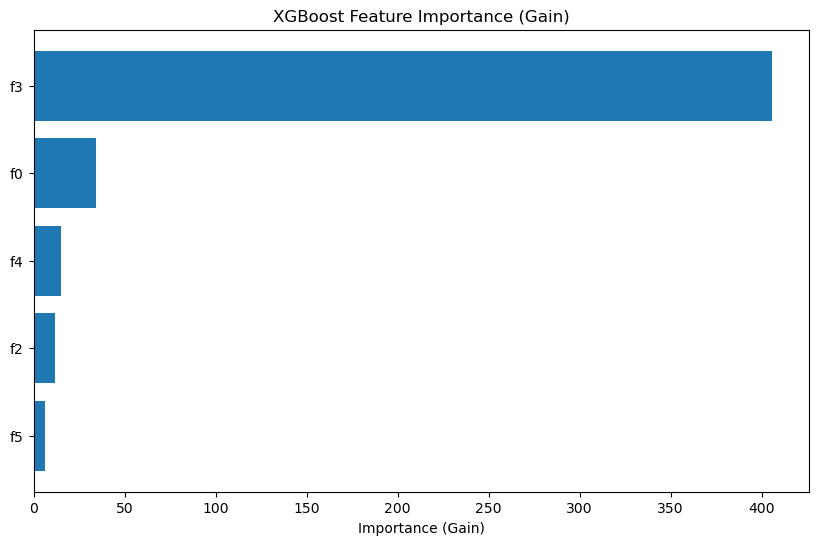

[('f3', 405.5774841308594),
 ('f0', 34.186378479003906),
 ('f4', 15.291656494140625),
 ('f2', 11.520660400390625),
 ('f5', 6.479923725128174)]

In [8]:
# ============================================
# 8. Feature importance (XGBoost gain)
# ============================================

import matplotlib.pyplot as plt
import xgboost as xgb_local  # bst already loaded above

# Get gain-based feature importance from the booster
importance = bst.get_score(importance_type="gain")

# Sort features by importance (descending)
importance_sorted = sorted(importance.items(), key=lambda x: x[1], reverse=True)

# Plot feature importance as a horizontal bar chart
plt.figure(figsize=(10, 6))
plt.barh([k for k, v in importance_sorted], [v for k, v in importance_sorted])
plt.gca().invert_yaxis()
plt.title("XGBoost Feature Importance (Gain)")
plt.xlabel("Importance (Gain)")
plt.show()

importance_sorted


## 9. SHAP explainability (using XGBoost built-in contributions)

We use XGBoost’s built‑in `pred_contribs=True` to compute SHAP‑style feature contributions  
without requiring the external `shap` library (which is not available in AWS Academy).


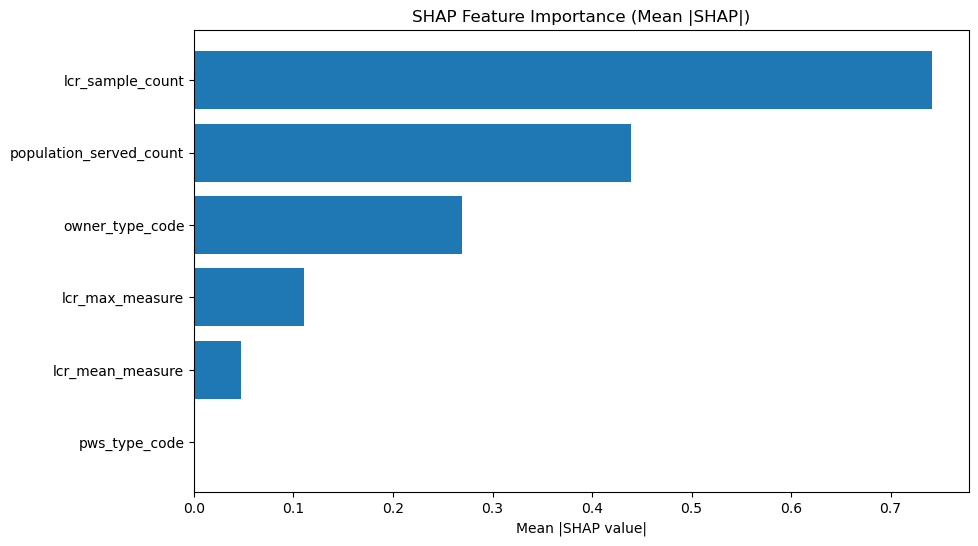

[('lcr_sample_count', 0.74161536),
 ('population_served_count', 0.43953067),
 ('owner_type_code', 0.26912108),
 ('lcr_max_measure', 0.11067559),
 ('lcr_mean_measure', 0.047132935),
 ('pws_type_code', 0.0)]

In [9]:
# ============================================
# 9. SHAP explainability (XGBoost built-in)
# ============================================

import numpy as np
import matplotlib.pyplot as plt

# Reuse the numeric test matrix from evaluation
dtest = xgb_local.DMatrix(X_test_local)

# Get SHAP values (feature contributions) from XGBoost
# The last column is the bias term, so we drop it.
shap_values = bst.predict(dtest, pred_contribs=True)
shap_values = shap_values[:, :-1]

# Compute mean absolute SHAP value per feature
mean_abs_shap = np.abs(shap_values).mean(axis=0)

# Pair SHAP values with feature names
feature_importance_shap = list(zip(X_train.columns, mean_abs_shap))
feature_importance_shap_sorted = sorted(feature_importance_shap, key=lambda x: x[1], reverse=True)

# Plot SHAP feature importance
plt.figure(figsize=(10, 6))
plt.barh(
    [x[0] for x in feature_importance_shap_sorted],
    [x[1] for x in feature_importance_shap_sorted],
)
plt.gca().invert_yaxis()
plt.title("SHAP Feature Importance (Mean |SHAP|)")
plt.xlabel("Mean |SHAP value|")
plt.show()

feature_importance_shap_sorted


## 10. Register trained model as a SageMaker Model

We wrap the trained XGBoost artifact and container image into a SageMaker `Model` object  
so it can be used for Batch Transform and, later, for monitoring.


In [10]:
# ============================================
# 10. Create SageMaker Model for Batch Transform
# ============================================

from sagemaker.model import Model

# Create a SageMaker Model object pointing to the trained artifact and container
xgb_model = Model(
    image_uri=xgb_image,
    model_data=xgb_estimator.model_data,
    role=role_arn,
    sagemaker_session=sm_session,
)

# Assign a stable model name for reuse
model_name = "xgb-week4-model"
xgb_model.name = model_name

# Register the model in SageMaker
xgb_model.create(instance_type="ml.m5.large")

print("Created model:", model_name)


INFO:sagemaker:Creating model with name: xgb-week4-model


Created model: xgb-week4-model


## 11. Batch Transform deployment (preprocessed numeric input)

We run a Batch Transform job using the trained model on the test split.  
The output will be used as a production‑style inference artifact and as input to Week‑5 monitoring.


In [ ]:
# ============================================
# 11. Batch Transform deployment (preprocessed input)
# ============================================

from sagemaker.transformer import Transformer

# S3 location where Batch Transform outputs will be written
transform_output = f"s3://{bucket}/{parquet_prefix}week4/batch-output/"

# --------------------------------------------
# Preprocess test data for Batch Transform
# --------------------------------------------

# Drop the label column; Batch Transform only needs features
bt_df = test_csv_df.drop(columns=["label_high_risk"]).copy()

# Convert all columns to numeric and fill missing values
bt_df = bt_df.apply(pd.to_numeric, errors="coerce").fillna(0)

# Save numeric-only CSV with no header for the XGBoost container
test_no_header_path = f"s3://{bucket}/{parquet_prefix}{features_table_name}_test_no_header.csv"
wr.s3.to_csv(bt_df, test_no_header_path, index=False, header=False)

print("Preprocessed Batch Transform input written to:", test_no_header_path)

# --------------------------------------------
# Run Batch Transform job
# --------------------------------------------

transformer = Transformer(
    model_name=model_name,
    instance_count=1,
    instance_type="ml.m5.large",
    output_path=transform_output,
    sagemaker_session=sm_session,
)

# Launch the transform job on the preprocessed test CSV
transformer.transform(
    data=test_no_header_path,
    content_type="text/csv",
    split_type="Line",
)
transformer.wait()

print("Batch Transform completed.")
print("Output path:", transform_output)


Preprocessed Batch Transform input written to: s3://aai540-group5-public-866792937762-us-east-1-an/sdwa/parquet/sdwa_pws_quarter_features_test_no_header.csv


INFO:sagemaker:Creating transform job with name: sagemaker-xgboost-2026-06-04-03-10-42-631


............

## 12. Retrieve Batch Transform Job Logs (Debugging & Verification)

When a Batch Transform job fails or behaves unexpectedly, SageMaker provides detailed  
runtime logs through CloudWatch. These logs contain:

- Input parsing errors  
- CSV formatting issues  
- Container‑level exceptions  
- Model loading errors  
- Memory or instance‑type issues  

This cell retrieves the logs for the **most recent Batch Transform job**, prints the  
job status and failure reason, and then streams the CloudWatch log events so we can  
inspect the exact cause of failure.

This is essential for debugging production inference pipelines.


In [ ]:
# ============================================
# 12. Fetch Batch Transform Job Logs
# ============================================

import boto3

# Create a SageMaker client for interacting with transform jobs
sm_client = boto3.client("sagemaker")

# ------------------------------------------------------------
# Step 1: Identify the most recent Batch Transform job
# ------------------------------------------------------------
# We sort transform jobs by creation time (descending) and take the newest one.
jobs = sm_client.list_transform_jobs(
    SortBy="CreationTime",
    SortOrder="Descending"
)

job_name = jobs["TransformJobSummaries"][0]["TransformJobName"]
print("Most recent transform job:", job_name)

# ------------------------------------------------------------
# Step 2: Describe the job to get high-level status and failure reason
# ------------------------------------------------------------
desc = sm_client.describe_transform_job(TransformJobName=job_name)

print("\nJob Status:", desc["TransformJobStatus"])
print("Failure Reason:", desc.get("FailureReason", "None"))

# ------------------------------------------------------------
# Step 3: Retrieve CloudWatch logs for detailed debugging
# ------------------------------------------------------------
cw = boto3.client("logs")

# All Batch Transform logs are stored under this log group
log_group = "/aws/sagemaker/TransformJobs"

# We retrieve the most recent log stream for this job
streams = cw.describe_log_streams(
    logGroupName=log_group,
    orderBy="LastEventTime",
    descending=True,
    limit=1
)

if streams["logStreams"]:
    stream_name = streams["logStreams"][0]["logStreamName"]
    print("\nLog Stream:", stream_name)

    # ------------------------------------------------------------
    # Step 4: Fetch and print all log events from the stream
    # ------------------------------------------------------------
    events = cw.get_log_events(
        logGroupName=log_group,
        logStreamName=stream_name,
        startFromHead=True
    )

    print("\n=== CloudWatch Logs ===")
    for e in events["events"]:
        print(e["message"])

else:
    print("No log streams found.")


## 13. Monitoring prep: feature schema and baseline statistics

We generate:

- A feature schema describing feature names and dtypes  
- Baseline statistics for numeric features and label distribution  

These artifacts will be used in Week‑5 for model monitoring and drift detection.


In [ ]:
# ============================================
# 13. Monitoring prep (schema + baseline stats)
# ============================================

import json
import numpy as np
import pandas as pd

# S3 locations for monitoring artifacts
monitor_prefix = f"{parquet_prefix}week5_monitoring/"
schema_path    = f"s3://{bucket}/{monitor_prefix}feature_schema.json"
baseline_path  = f"s3://{bucket}/{monitor_prefix}training_baseline_stats.json"

# ---------------------------
# Feature schema
# ---------------------------
feature_schema = {
    "features": [
        {"name": col, "dtype": str(X_train[col].dtype)}
        for col in X_train.columns
    ],
    "label": {"name": "label_high_risk", "dtype": str(y_train.dtype)},
}

# ---------------------------
# Baseline statistics
# ---------------------------
baseline_stats = {
    "row_count": int(len(train_csv_df)),
    "label_distribution": {
        "0": int((y_train == 0).sum()),
        "1": int((y_train == 1).sum()),
    },
    "numeric_feature_summary": {},
}

# Use pandas' numeric type detection to avoid dtype issues
numeric_cols = X_train.select_dtypes(include=["number"]).columns

for col in numeric_cols:
    # Coerce to numeric and compute summary stats
    series = pd.to_numeric(X_train[col], errors="coerce")
    baseline_stats["numeric_feature_summary"][col] = {
        "mean": float(series.mean()),
        "std": float(series.std()),
        "min": float(series.min()),
        "max": float(series.max()),
    }

# ---------------------------
# Write artifacts to S3 as JSON
# ---------------------------
wr.s3.to_json(pd.Series([json.dumps(feature_schema)]), schema_path)
wr.s3.to_json(pd.Series([json.dumps(baseline_stats)]), baseline_path)

print("Monitoring artifacts written.")
print("Schema path   :", schema_path)
print("Baseline path :", baseline_path)
